## **Assignment Overview: Credit Default Risk Prediction**

## **Names: EKIRU ERNEST OCHEPA**

## **DATA PREPARATION**

In [4]:
# Calling libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Importing dataset
df = pd.read_csv('credit_default_dataset.csv')

# Checking structure of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CustomerID          1000 non-null   int64  
 1   Age                 930 non-null    float64
 2   Gender              1000 non-null   object 
 3   MaritalStatus       1000 non-null   object 
 4   Education           1000 non-null   object 
 5   Income              930 non-null    float64
 6   CreditScore         930 non-null    float64
 7   LoanAmount          930 non-null    float64
 8   LoanTerm            1000 non-null   int64  
 9   NumOfCreditCards    1000 non-null   int64  
 10  NumOfLatePayments   1000 non-null   int64  
 11  HasDefaultedBefore  1000 non-null   bool   
 12  Default             1000 non-null   int64  
dtypes: bool(1), float64(4), int64(5), object(3)
memory usage: 94.9+ KB


There are 1000 entries and 12 variables in our dataset
There are 4 variables with missing values that is Age, Income, CreditScore, and LoanAmount.

### **Checking for duplicates**

In [6]:
duplicate_count = df.duplicated(subset=["CustomerID"]).sum()
print("Number of duplicate ID's: ", duplicate_count)

Number of duplicate ID's:  0


There are no duplicated entries

#### **Checking missing values**

In [7]:
# Counting the missing values
missing_count = df.isnull().sum()
print(missing_count)

CustomerID             0
Age                   70
Gender                 0
MaritalStatus          0
Education              0
Income                70
CreditScore           70
LoanAmount            70
LoanTerm               0
NumOfCreditCards       0
NumOfLatePayments      0
HasDefaultedBefore     0
Default                0
dtype: int64


In [8]:
# Converting to percentages
missing_percent = (missing_count / len(df)) * 100
print(missing_percent)

CustomerID            0.0
Age                   7.0
Gender                0.0
MaritalStatus         0.0
Education             0.0
Income                7.0
CreditScore           7.0
LoanAmount            7.0
LoanTerm              0.0
NumOfCreditCards      0.0
NumOfLatePayments     0.0
HasDefaultedBefore    0.0
Default               0.0
dtype: float64


In [9]:
# Organizing into a table
missing_data = pd.DataFrame({'count': missing_count, 'percent': missing_percent})
print(missing_data)

                    count  percent
CustomerID              0      0.0
Age                    70      7.0
Gender                  0      0.0
MaritalStatus           0      0.0
Education               0      0.0
Income                 70      7.0
CreditScore            70      7.0
LoanAmount             70      7.0
LoanTerm                0      0.0
NumOfCreditCards        0      0.0
NumOfLatePayments       0      0.0
HasDefaultedBefore      0      0.0
Default                 0      0.0


There missing values are not severe since all are way below 50%, therefore, the missing values will be imputed

### **Handling the missing data variables**

#### ***Age***

In [10]:
# Understanding distribution
df["Age"].describe().round(2)

count    930.00
mean      44.44
std       15.30
min       18.00
25%       32.00
50%       45.00
75%       57.00
max       70.00
Name: Age, dtype: float64

In [11]:
from scipy.stats import shapiro

age_clean = df["Age"].dropna()
stat, p = shapiro(age_clean)
print('Shapiro-Wilk Test: Statistics=%.3f, p=%.3f' % (stat, p))
alpha = 0.05

if p > 0.05:
    print('Sample is normally distributed')
else:
    print('Sample is not normally distributed')

Shapiro-Wilk Test: Statistics=0.957, p=0.000
Sample is not normally distributed


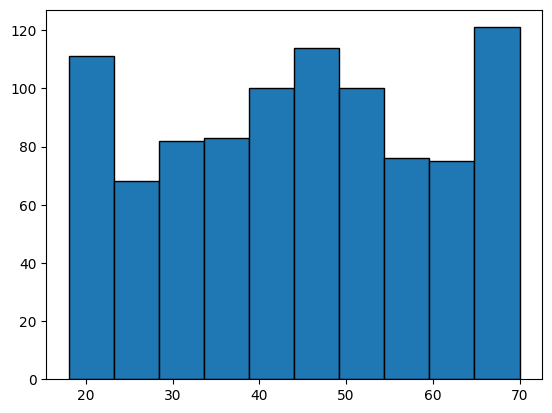

In [12]:
# Visualizing the distribution
plt.hist(df["Age"], bins=10, density=False, edgecolor='black')

plt.show()

Since the sample (Age variables) is not normally distributed (confirmed by the "shapiro test" and the "histogram plot"), the median will be used to impute the missing values.

In [13]:
# Imputing using the median age
median_age = df["Age"].median()
df["Age"].fillna(median_age, inplace=True)


C:\Users\ekiru\AppData\Local\Temp\ipykernel_16508\2182632381.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(median_age, inplace=True)


In [14]:
# Confirming no missing values remain
print(df["Age"].isnull().sum()) 

0


Missing values in the age variable have been handled

#### ***Income***

In [15]:
# Understanding distribution
df["Income"].describe().round(2)

count       930.00
mean      86670.75
std       37324.96
min       20057.56
25%       54686.54
50%       88807.02
75%      119117.12
max      149962.79
Name: Income, dtype: float64

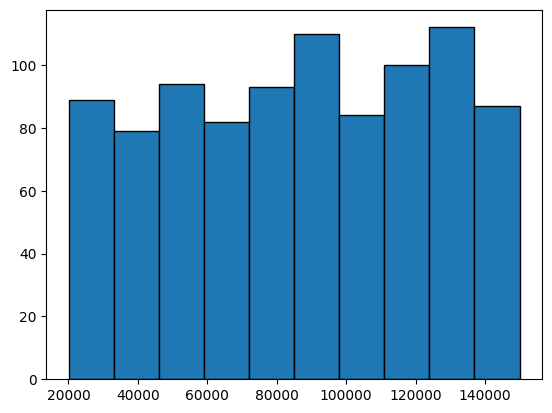

In [16]:
# Visualizing the distribution
plt.hist(df["Income"], bins=10, density=False, edgecolor='black')

plt.show()

In [17]:
# Confirming the distribtution using Shapiro-Wilk test
from scipy.stats import shapiro
Income_clean = df["Income"].dropna()

stat, p = shapiro(Income_clean)
print('Statistics=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Sample is normally distributed')
else:
    print('Sample is not normally distributed')

Statistics=0.955, p=0.000
Sample is not normally distributed


Since the sample (Income variables) is not normally distributed (confirmed by the "shapiro test" and the "histogram plot"), the median will be used to impute the missing values.

In [18]:
# Imputing using the median Income
median_income = df["Income"].median()
df["Income"].fillna(median_income, inplace=True)


# Confirming no missing values remain
print(df["Income"].isnull().sum()) 

0


C:\Users\ekiru\AppData\Local\Temp\ipykernel_16508\3325405900.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Income"].fillna(median_income, inplace=True)


No More missing values under the income variable

#### ***Credit Score***

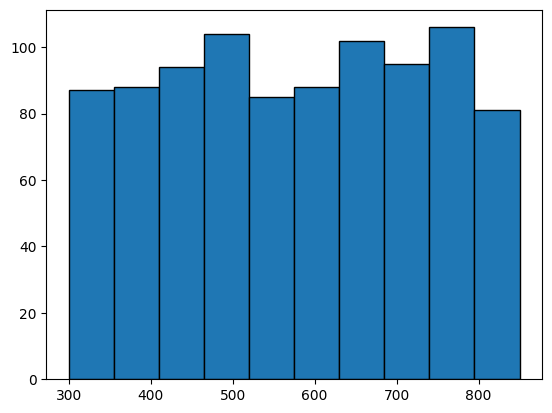

In [19]:
# Visualizing the distribution
plt.hist(df["CreditScore"], bins=10, density=False, edgecolor='black')

plt.show()

In [20]:
# Confirming the distribtution using Shapiro-Wilk test
from scipy.stats import shapiro

Creditscore_clean = df["CreditScore"].dropna()

stat, p = shapiro(Creditscore_clean)
print('Statistics=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Sample is normally distributed')
else:
    print('Sample is not normally distributed')

Statistics=0.955, p=0.000
Sample is not normally distributed


Therefore, the Credit score variables will be imputed using the median Credit score

In [21]:
# Imputing using the median creditscore
median_creditscore = df["CreditScore"].median()
df["CreditScore"].fillna(median_creditscore, inplace=True)

# Confirming no missing values remain
print(df["CreditScore"].isnull().sum()) 

0


C:\Users\ekiru\AppData\Local\Temp\ipykernel_16508\3671284278.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["CreditScore"].fillna(median_creditscore, inplace=True)


No more missing values under the Credit score variable

#### ***Loan Amount***

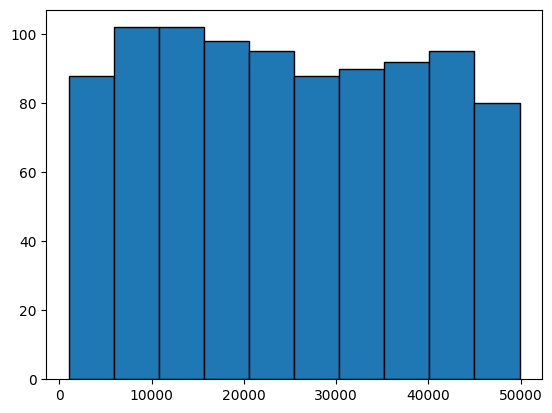

In [22]:
# Visualizing the distribution
plt.hist(df["LoanAmount"], bins=10, density=False, edgecolor='black')

plt.show()

In [23]:
# Confirming the distribtution using Shapiro-Wilk test
from scipy.stats import shapiro
Loanamount_clean = df["LoanAmount"].dropna()

stat, p = shapiro(Loanamount_clean)
print('Statistics=%.3f, p=%.3f' % (stat, p))
if p > 0.05:
    print('Sample is normally distributed')
else:
    print('Sample is not normally distributed')

Statistics=0.956, p=0.000
Sample is not normally distributed


Since the data is not mormally distributed, the median value will be used for imputation

In [24]:
# Imputing using the median Loan amount

median_loanamount = df["LoanAmount"].median()
df["LoanAmount"].fillna(median_loanamount, inplace=True)

# Confirming no missing values remain
print(df["LoanAmount"].isnull().sum()) 

0


C:\Users\ekiru\AppData\Local\Temp\ipykernel_16508\2525293565.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["LoanAmount"].fillna(median_loanamount, inplace=True)


#### ***Confirming whether all missin values have been handles***

In [25]:
# Counting the missing values
missing_count = df.isnull().sum()
print(missing_count)

CustomerID            0
Age                   0
Gender                0
MaritalStatus         0
Education             0
Income                0
CreditScore           0
LoanAmount            0
LoanTerm              0
NumOfCreditCards      0
NumOfLatePayments     0
HasDefaultedBefore    0
Default               0
dtype: int64


# Exploratory Data Analysis

### **Age**

In [26]:
df["Age"].describe().round(2)

count    1000.00
mean       44.48
std        14.75
min        18.00
25%        33.00
50%        45.00
75%        56.00
max        70.00
Name: Age, dtype: float64

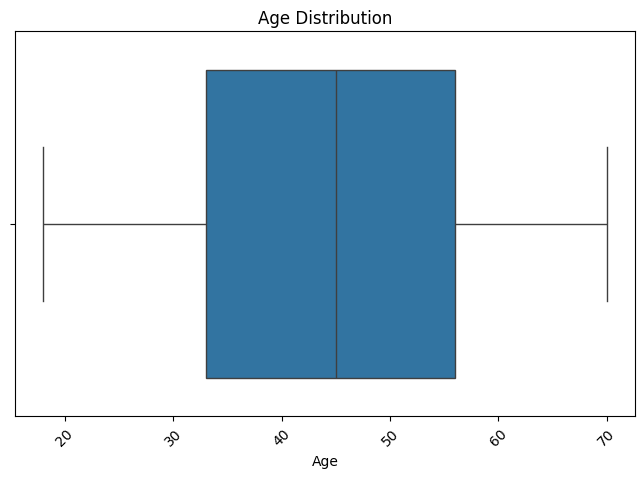

In [27]:
# Visualizing Age distribution
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='Age', data=df)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.xticks(rotation=45)
plt.savefig("Age", dpi=300, bbox_inches="tight")
plt.show()

The mean age of the clients was 44 years, with the maximum being 70 years and the minimum being 18 years

### **Gender**

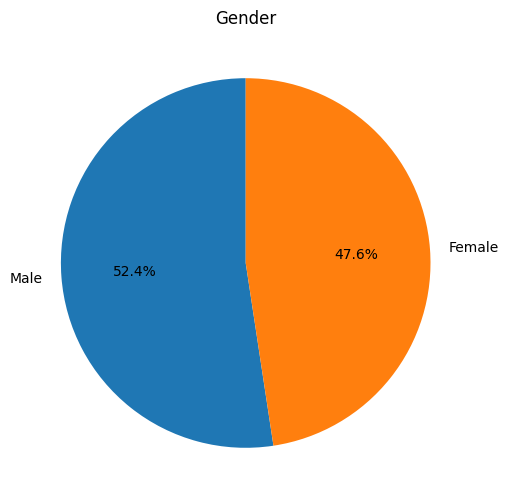

In [28]:
# Pie chart
gender_count = df["Gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    gender_count,
    labels=gender_count.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=False
)
plt.title("Gender")
plt.savefig("Gender", dpi=300, bbox_inches="tight")
plt.show()

There were more males (52.5%) than females (47.6%)

### ***Marital Status***

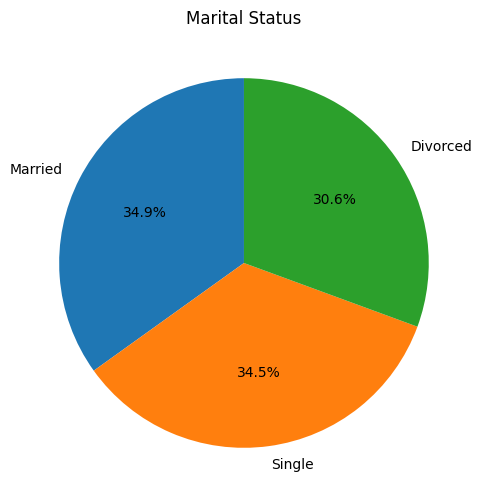

In [29]:
# Pie chart
marital_count = df["MaritalStatus"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    marital_count,
    labels=marital_count.index,
    autopct='%1.1f%%',
    startangle=90,
    shadow=False
)
plt.title("Marital Status")
plt.savefig("Marital_status", dpi=300, bbox_inches="tight")
plt.show()

There were more respondent who were married (34.9%), followed by the Singles (34.5%), then lastly the Divorced (30.6%)

### **Education level**

In [30]:
education_count = df['Education'].value_counts()
education_percent = df['Education'].value_counts(normalize=True) * 100

education_summary = pd.DataFrame({
    "frequency" : education_count,
    "percentage" : education_percent.round(1)
})
print(education_summary)

             frequency  percentage
Education                         
PhD                276        27.6
Bachelor           244        24.4
High School        242        24.2
Master             238        23.8


In [31]:
# Generating new education dataset
education_df = education_count.reset_index()
education_df.columns = ["education", "count"]
education_df["percentage"] = education_percent.values

order = education_df["education"].tolist()

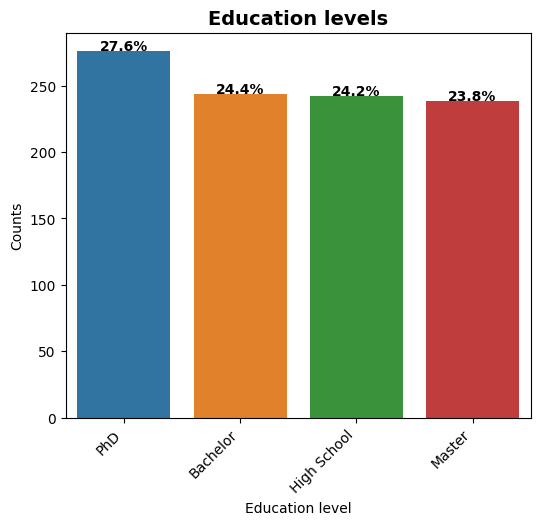

In [32]:
# Bar graphs
plt.figure(figsize=(6,5))
ax = sns.barplot(data=education_df, x="education", y="count", hue="education",order=order, legend=False)

for i, row in education_df.iterrows():
    ax.text(i, row["count"] + 0.5, f"{row['percentage']:.1f}%", 
            ha='center', fontsize=10, fontweight="bold")

plt.title("Education levels", fontsize=14, fontweight="bold")
plt.xlabel("Education level")
plt.ylabel("Counts")

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.savefig("Educ", dpi=300, bbox_inches="tight")
plt.show()

The clients with PhD level of education were the majority (27.6%), followed by those with a Bachelors, high school, then Masters

### **Income**

In [33]:
df["Income"].describe().round(2)

count      1000.00
mean      86820.28
std       35997.66
min       20057.56
25%       57026.80
50%       88807.02
75%      116637.21
max      149962.79
Name: Income, dtype: float64

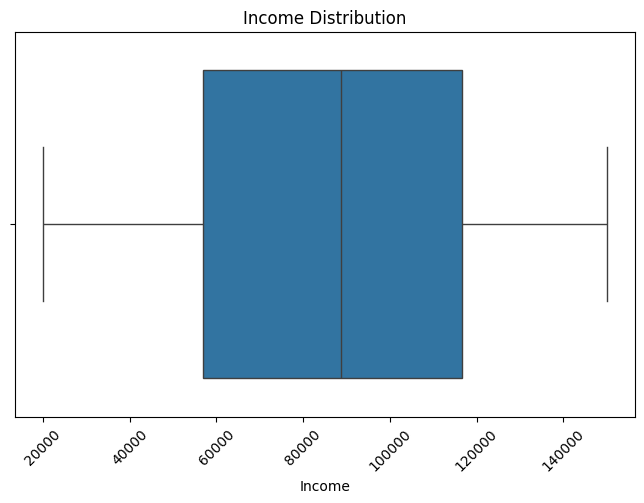

In [34]:
# Visualizing Age distribution
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='Income', data=df)
plt.title("Income Distribution")
plt.xlabel("Income")
plt.xticks(rotation=45)
plt.show()

### **Credit Score**

In [35]:
df["CreditScore"].describe().round(2)

count    1000.00
mean      576.55
std       151.54
min       300.00
25%       453.25
50%       577.50
75%       705.00
max       850.00
Name: CreditScore, dtype: float64

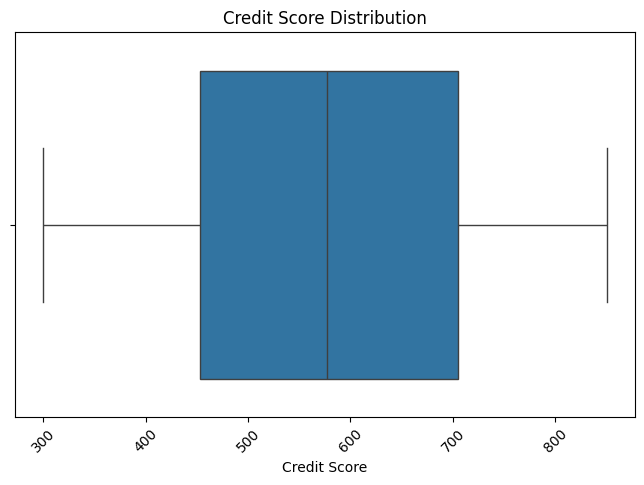

In [36]:
# Visualizing Age distribution
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='CreditScore', data=df)
plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")

plt.xticks(rotation=45)
plt.show()

### **Loan Amount**

In [37]:
df["LoanAmount"].describe().round(2)

count     1000.00
mean     24784.17
std      13462.89
min       1009.14
25%      13702.19
50%      24344.80
75%      36060.25
max      49878.39
Name: LoanAmount, dtype: float64

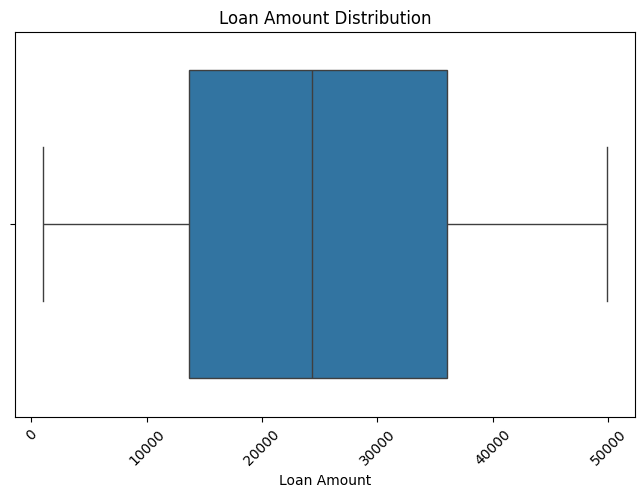

In [38]:
# Visualizing Age distribution
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='LoanAmount', data=df)
plt.title("Loan Amount Distribution")
plt.xlabel("Loan Amount")

plt.xticks(rotation=45)
plt.show()

### **Generating new variables**

This is to identify hidden parttern / information with the data that might be important to understand the Customers behavior

In [39]:
# Debit to Income ratio
# Debit = LoanAmount
df['DebtToIncome'] = df['LoanAmount'] / df['Income']


In [40]:
# Credit utilization per credit card
# Measuring how much loan amount is per credit card held by the customer
df['LoanPerCard'] = df['LoanAmount'] / (df['NumOfCreditCards'] + 1)


In [41]:
# Average late payments per month
# This shows the displine of the customer in making payments
df['LatePaymentsPerMonth'] = df['NumOfLatePayments'] / df['LoanTerm']


In [42]:
# Detecting behavioral patterns based on age groups
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[18, 30, 45, 60, np.inf],
    labels=['Young', 'MidAge', 'Mature', 'Elderly']
)


In [43]:
df.head()

,CustomerID,Age,Gender,MaritalStatus,Education,Income,CreditScore,LoanAmount,LoanTerm,NumOfCreditCards,NumOfLatePayments,HasDefaultedBefore,Default,DebtToIncome,LoanPerCard,LatePaymentsPerMonth,AgeGroup
0,1,56.0,Male,Married,PhD,89810.97,577.5,3994.13,24,6,10,False,1,0.044473,570.590000,0.416667,Mature
1,2,69.0,Male,Married,High School,131037.68,634.0,25465.84,48,8,7,True,0,0.194340,2829.537778,0.145833,Elderly
2,3,46.0,Female,Single,PhD,26434.59,415.0,6210.53,12,7,1,True,0,0.234940,776.316250,0.083333,Mature
3,4,32.0,Female,Divorced,High School,128331.22,348.0,6592.86,48,8,0,True,1,0.051374,732.540000,0.000000,MidAge
4,5,60.0,Female,Single,Master,129710.20,381.0,47111.36,60,7,9,False,0,0.363205,5888.920000,0.150000,Mature


## **Bivariate Analysis**

### **Column names**

In [44]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'Education', 'Income',
       'CreditScore', 'LoanAmount', 'LoanTerm', 'NumOfCreditCards',
       'NumOfLatePayments', 'HasDefaultedBefore', 'Default', 'DebtToIncome',
       'LoanPerCard', 'LatePaymentsPerMonth', 'AgeGroup'],
      dtype='object')

### **Droping irrelevant variables**

In [45]:
df1 = df.drop(columns=['CustomerID','Age'])
df1.columns # confirming changes

Index(['Gender', 'MaritalStatus', 'Education', 'Income', 'CreditScore',
       'LoanAmount', 'LoanTerm', 'NumOfCreditCards', 'NumOfLatePayments',
       'HasDefaultedBefore', 'Default', 'DebtToIncome', 'LoanPerCard',
       'LatePaymentsPerMonth', 'AgeGroup'],
      dtype='object')

### **Encoding the variables - converting to numeric variables**

In [46]:
from sklearn.preprocessing import LabelEncoder

# Re-coding variables
le = LabelEncoder()

for column in df1.columns:
    if df1[column].dtype == 'object' or str(df1[column].dtype) == 'category':
        df1[column] = le.fit_transform(df1[column].astype(str))

print(df1.head(), '\n')
print(df1.info())


   Gender  MaritalStatus  Education     Income  CreditScore  LoanAmount  \
0       1              1          3   89810.97        577.5     3994.13   
1       1              1          1  131037.68        634.0    25465.84   
2       0              2          3   26434.59        415.0     6210.53   
3       0              0          1  128331.22        348.0     6592.86   
4       0              2          2  129710.20        381.0    47111.36   

   LoanTerm  NumOfCreditCards  NumOfLatePayments  HasDefaultedBefore  Default  \
0        24                 6                 10               False        1   
1        48                 8                  7                True        0   
2        12                 7                  1                True        0   
3        48                 8                  0                True        1   
4        60                 7                  9               False        0   

   DebtToIncome  LoanPerCard  LatePaymentsPerMonth  AgeGroup  

### **Correlation Matrix**

This is to identify any form of multicollinearity

In [47]:
# Correlation Analysis

correlation_matrix = df1.corr()

correlation_matrix

,Gender,MaritalStatus,Education,Income,CreditScore,LoanAmount,LoanTerm,NumOfCreditCards,NumOfLatePayments,HasDefaultedBefore,Default,DebtToIncome,LoanPerCard,LatePaymentsPerMonth,AgeGroup
Gender,1.000000,0.008855,-0.051351,0.009343,-0.034307,-0.046730,0.032296,0.010838,-0.016645,0.008196,0.009249,0.014118,-0.018853,-0.042163,-0.060502
MaritalStatus,0.008855,1.000000,-0.085607,-0.043349,0.026313,-0.023859,-0.049242,-0.001481,0.010312,-0.017577,-0.013465,0.011998,-0.020969,0.031612,0.002816
Education,-0.051351,-0.085607,1.000000,0.023190,0.026389,0.001393,0.024080,0.017034,-0.048346,0.028571,0.013267,0.011262,-0.022505,-0.056489,0.003052
Income,0.009343,-0.043349,0.023190,1.000000,0.029230,0.015889,0.027686,0.003677,0.004744,0.009321,0.015358,-0.603512,-0.014731,-0.010318,0.008974
CreditScore,-0.034307,0.026313,0.026389,0.029230,1.000000,0.070732,0.009228,0.057564,0.036724,-0.042309,-0.260671,0.020240,0.006529,0.025327,-0.001497
LoanAmount,-0.046730,-0.023859,0.001393,0.015889,0.070732,1.000000,0.013858,0.016931,-0.007277,0.028510,0.181048,0.595043,0.429257,-0.015888,-0.004255
LoanTerm,0.032296,-0.049242,0.024080,0.027686,0.009228,0.013858,1.000000,-0.014470,0.024187,-0.006004,-0.027934,-0.020524,0.025792,-0.561731,-0.034383
NumOfCreditCards,0.010838,-0.001481,0.017034,0.003677,0.057564,0.016931,-0.014470,1.000000,-0.053572,0.008878,-0.036006,0.017961,-0.630112,-0.015412,0.005749
NumOfLatePayments,-0.016645,0.010312,-0.048346,0.004744,0.036724,-0.007277,0.024187,-0.053572,1.000000,0.065391,0.189234,-0.042681,0.022345,0.649472,0.015561
HasDefaultedBefore,0.008196,-0.017577,0.028571,0.009321,-0.042309,0.028510,-0.006004,0.008878,0.065391,1.000000,0.214579,0.034776,0.010671,0.034092,-0.005112


### **Visualizing the correlation matrix**

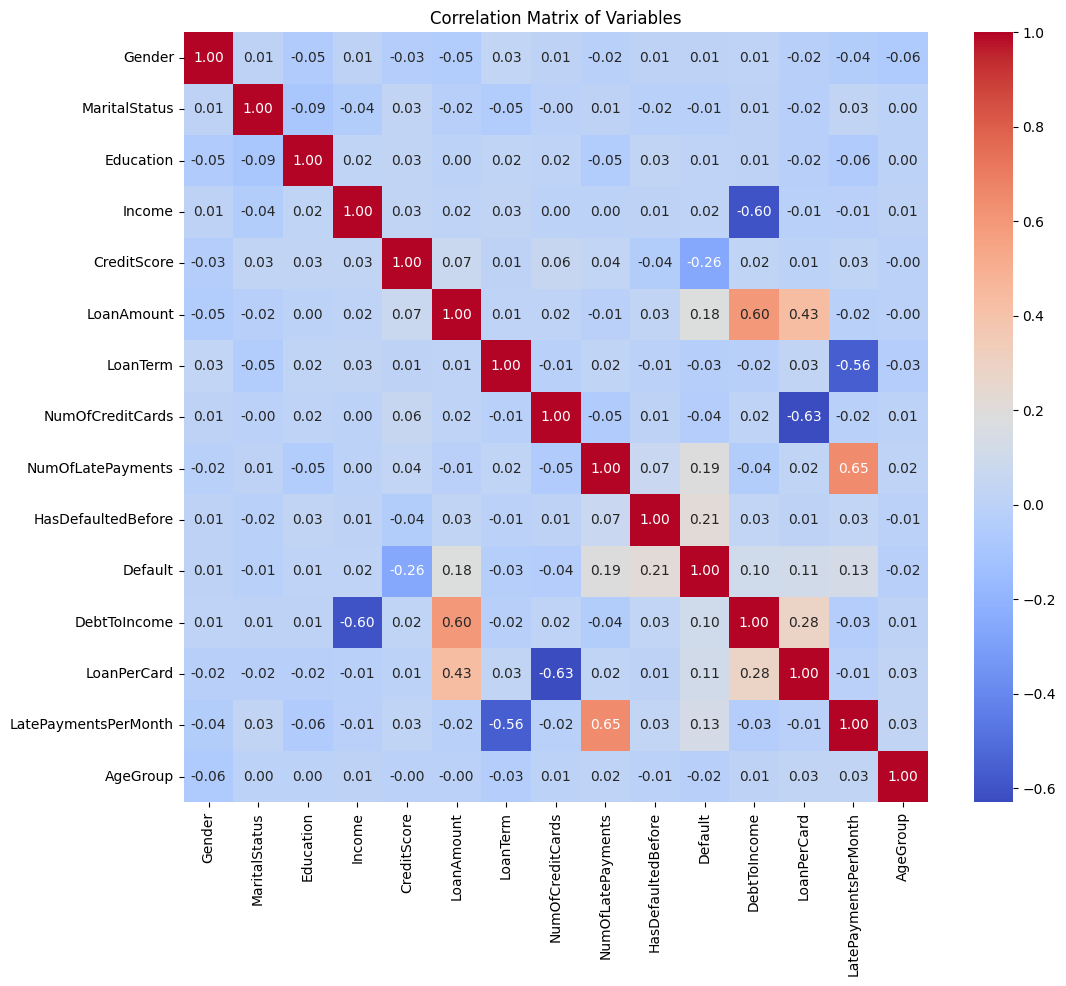

In [48]:

# Calculate the correlation matrix
corr_matrix = df1.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Variables')
plt.savefig("Correlation Matrix", dpi=300, bbox_inches="tight")
plt.show()

There are multicollinear variaibles identified

DebtToIncome and Income = -0.56
DebtToIncome and LoanAmount = 0.64
LoanPercard and NumofCreditCard = -0.60
LatePaymentsPerMonth and LoanTerm = -0.56
LatePaymentsPerMonth and Numoflatepayments = -0.65

Therefore, DebtToIncome, NumofCreditCard, LatePaymentsPerMonth will be dropped

### **Deleting the multicollinear variables**

In [49]:
df2 = df1.drop(columns=['DebtToIncome', 'NumOfCreditCards', 'LatePaymentsPerMonth'])
df2.columns # confirming changes

Index(['Gender', 'MaritalStatus', 'Education', 'Income', 'CreditScore',
       'LoanAmount', 'LoanTerm', 'NumOfLatePayments', 'HasDefaultedBefore',
       'Default', 'LoanPerCard', 'AgeGroup'],
      dtype='object')

### **libraries**

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, roc_auc_score,classification_report, confusion_matrix)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

In [51]:
# Generating the X and y dataset
X = df2[['Gender','MaritalStatus','Education','Income','CreditScore','LoanAmount','LoanTerm','NumOfLatePayments','HasDefaultedBefore','LoanPerCard','AgeGroup']]

y = df2['Default']

In [52]:
# Categorizing features
numeric_features = ['Income','CreditScore','LoanAmount','LoanTerm','NumOfLatePayments','HasDefaultedBefore','LoanPerCard']
categorical_features = ['Gender','MaritalStatus','Education','AgeGroup']

# Preprocessing pipelines
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


In [53]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Target distribution in train set:")
print(y_train.value_counts(normalize=True))

Train shape: (800, 11)
Test shape: (200, 11)
Target distribution in train set:
Default
0    0.55375
1    0.44625
Name: proportion, dtype: float64


The training dataset had 800 observation and the testing dataset had 200 observations.

there was no class imbalance in the target variable

## **Logistic Regression Model**

In [54]:
# Creating a pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

In [55]:
# Training the model
model.fit(X_train, y_train)

# Making predictions
y_pred_lr = model.predict(X_test)
y_proba_lr = model.predict_proba(X_test)[:, 1]

# Evaluation
print("Baseline Model Performance (Logistic Regression):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_lr):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['No Defaulting', 'Defaulting']))

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Baseline Model Performance (Logistic Regression):
Accuracy: 0.690
ROC-AUC:  0.743

Classification Report:
               precision    recall  f1-score   support

No Defaulting       0.69      0.80      0.74       111
   Defaulting       0.69      0.55      0.61        89

     accuracy                           0.69       200
    macro avg       0.69      0.68      0.68       200
 weighted avg       0.69      0.69      0.68       200

Confusion Matrix:
[[89 22]
 [40 49]]


The logistic regression model achieved and accuracy of 69% and an AUC of 74.3%

### **Fine tuning the Logistic Regression model**

In [56]:
from sklearn.model_selection import GridSearchCV

In [57]:
# Generating a pipeline with GridSearchCV for hyperparameter tuning
model_1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear', random_state=123))
])

# Defining parameters
param_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2']
}

# Grid search
grid_lr = GridSearchCV(
    model_1,
    param_grid=param_lr,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

# Fitting the model
grid_lr.fit(X_train, y_train)

print("Best Logistic Regression parameters found: ", grid_lr.best_params_)
print(f"Best ROC-AUC: {grid_lr.best_score_:.3f}")

Best Logistic Regression parameters found:  {'classifier__C': 0.1, 'classifier__penalty': 'l1'}
Best ROC-AUC: 0.736


C:\Users\ekiru\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\ekiru\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


In [58]:
# making predictions with the tuned model
y_pred_tuned = grid_lr.predict(X_test)
y_proba_tuned = grid_lr.predict_proba(X_test)[:, 1]

# Evaluation the tuned model
print("Model Performance Logistic Regression:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_tuned):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_tuned):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['Low Traffic', 'High Traffic']))

Model Performance Logistic Regression:
Accuracy: 0.685
ROC-AUC:  0.751

Classification Report:
              precision    recall  f1-score   support

 Low Traffic       0.69      0.78      0.73       111
High Traffic       0.68      0.56      0.61        89

    accuracy                           0.69       200
   macro avg       0.68      0.67      0.67       200
weighted avg       0.68      0.69      0.68       200



After fine tuning, the logistic regression model slightly improve scoring and Accuracy of 68.5% and AUC of 75.1%

## **Random Forest**

In [59]:
from sklearn.ensemble import RandomForestClassifier

In [60]:
# Defining pipeline
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Training the model
rf_model.fit(X_train, y_train)

# making predictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [61]:
# Evaluation
print("Baseline Model Performance (Random Forest):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_rf):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['No Defaulting', 'Defaulting']))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Baseline Model Performance (Random Forest):
Accuracy: 0.670
ROC-AUC:  0.740

Classification Report:
               precision    recall  f1-score   support

No Defaulting       0.68      0.77      0.72       111
   Defaulting       0.66      0.54      0.59        89

     accuracy                           0.67       200
    macro avg       0.67      0.66      0.66       200
 weighted avg       0.67      0.67      0.66       200

Confusion Matrix:
[[86 25]
 [41 48]]


The random forest model achieved an accuracy of 67% and AUC of 74%

### **Fine tuning the Random Forest model**

In [62]:
# Defining pipeline
rf_model_1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=123))
])

# Defining parameters
param_rf = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [5, 10, 15, None],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__max_features': ['sqrt', 'log2']
}

# Grid search
grid_rf = GridSearchCV(rf_model_1, param_rf, cv=5, scoring="roc_auc", n_jobs=-1)

# Fitting the model
grid_rf.fit(X_train, y_train)

print("Best Random Forest parameters found: ", grid_rf.best_params_)
print(f"Best ROC-AUC: {grid_rf.best_score_:.3f}")

Best Random Forest parameters found:  {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best ROC-AUC: 0.722


In [63]:
# Making predictions
y_pred_rf_tuned = grid_rf.predict(X_test)
y_proba_rf_tuned = grid_rf.predict_proba(X_test)[:, 1]

# Evaluations
print("Model Performance (Random Forest):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_tuned):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_proba_rf_tuned):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_tuned, target_names=['Low Traffic', 'High Traffic']))

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_tuned))

Model Performance (Random Forest):
Accuracy: 0.710
ROC-AUC:  0.768

Classification Report:
              precision    recall  f1-score   support

 Low Traffic       0.71      0.82      0.76       111
High Traffic       0.72      0.57      0.64        89

    accuracy                           0.71       200
   macro avg       0.71      0.70      0.70       200
weighted avg       0.71      0.71      0.70       200

Confusion Matrix:
[[91 20]
 [38 51]]


The random forest model achieved an Accuracy of 71% and AUC of 77%

## **Model Performance**

### **Model performance before fine tuning**

In [64]:
# Comparing model performance
model_performance = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf)
    ]
})

print(model_performance)

                 Model  Accuracy   ROC_AUC
0  Logistic Regression      0.69  0.743193
1        Random Forest      0.67  0.740257


#### Visualizing model performance before fine tuning

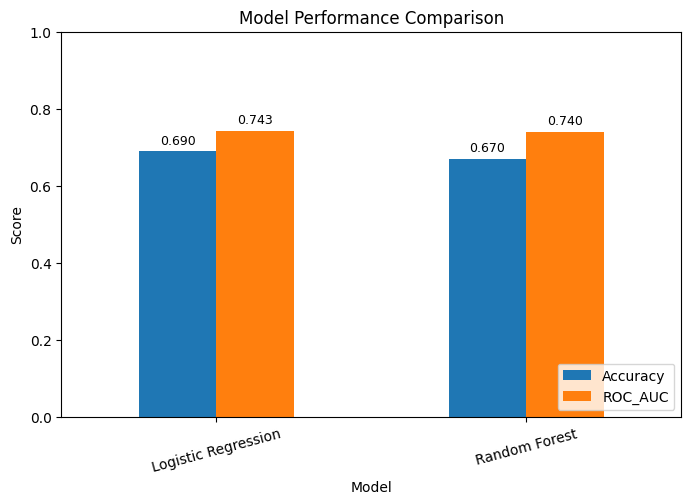

In [68]:
# Plotting performance comparison
ax = model_performance.plot(x='Model', y=['Accuracy', 'ROC_AUC'], kind='bar', figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='lower right')

# Annotate values on bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 3), textcoords='offset points')

plt.show()

### **Model Performance after fine tuning**

In [66]:
# Comparing model performance
model_performance_finetuned = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_tuned),
        accuracy_score(y_test, y_pred_rf_tuned)
    ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_proba_tuned),
        roc_auc_score(y_test, y_proba_rf_tuned)
    ]
})

print(model_performance_finetuned)

                 Model  Accuracy   ROC_AUC
0  Logistic Regression     0.685  0.750582
1        Random Forest     0.710  0.767993


#### Visualizing performance after fine tuning

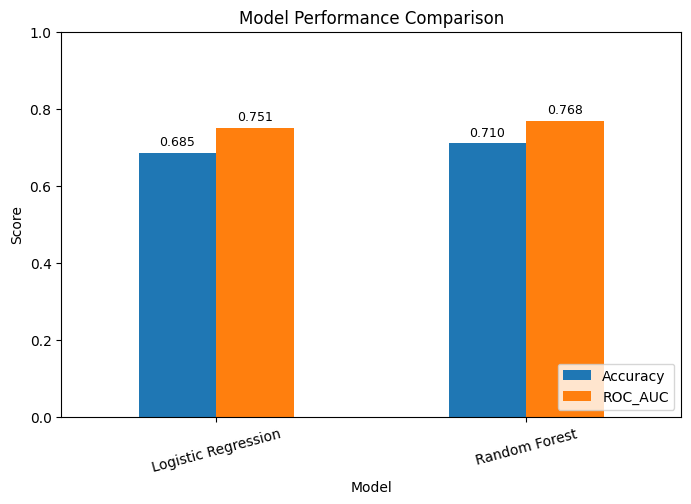

In [69]:
# Plotting performance comparison
ax = model_performance_finetuned.plot(x='Model', y=['Accuracy', 'ROC_AUC'], kind='bar', figsize=(8,5))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.legend(loc='lower right') 

# Annotate values on bars
for p in ax.patches:
    ax.annotate(f"{p.get_height():.3f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=9, color='black', xytext=(0, 3), textcoords='offset points')

plt.show()
